# ST40 Li powder dropper — axisymmetric, SOLPS background

**Author:** Abdourahmane (Abdou) Diaw (ORNL, diawa@ornl.gov)

Li grains fall from a top dropper, evaporate, ionise to Li3+ and follow field
lines. Background: SOLPS run 13589. Axi convention: x = Z, y = R.

In [9]:
from __future__ import annotations
import sys
from pathlib import Path
import numpy as np

ROOT          = Path.cwd().resolve()
if ROOT.name == "scripts":
    ROOT = ROOT.parent
if not (ROOT / "in.openedge").exists():
    ROOT = Path("examples/workflows/particulates/st40_lithium_powder_dropper").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

import importlib
import plot_lpd
plot_lpd = importlib.reload(plot_lpd)

INP           = ROOT / "input"


## 0. Sanity check: SOLPS plasma vs OpenEdge geometry

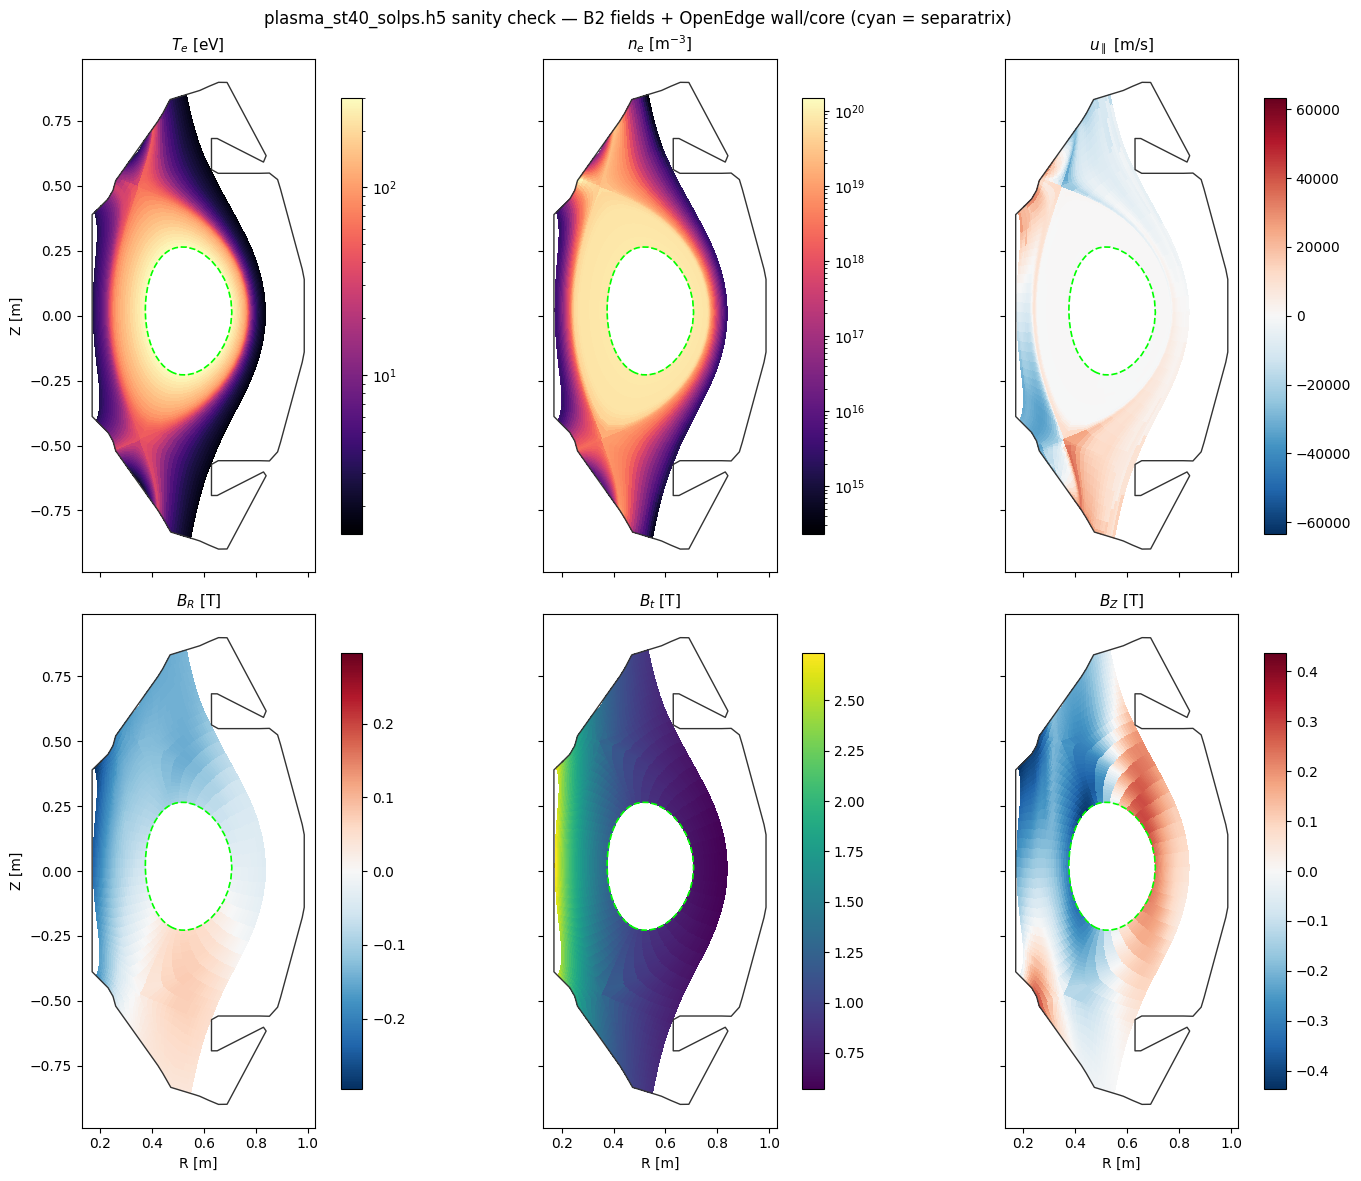

In [10]:
import h5py
from matplotlib import pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, TwoSlopeNorm

%matplotlib inline

def surf_loop_rz(path):
    pts = {}; mode = None
    for s in Path(path).read_text().splitlines():
        s = s.strip()
        if s.lower() == "points": mode = "p"; continue
        if s.lower() == "lines": mode = None; continue
        if mode == "p" and s and s[0].isdigit():
            a = s.split(); pts[int(a[0])] = (float(a[2]), float(a[1]))  # (R, Z)
    xy = [pts[i] for i in sorted(pts)] + [pts[1]]
    return np.array(xy)

with h5py.File(INP/"plasma_st40_solps.h5", "r") as f:
    polys = f["b2/cell_polygons"][:]          # (ncell, 4, 2) B2 quad cells
    fields = {k: f[f"b2/{k}"][:] for k in
              ("temp_e", "dens_e", "parr_flow", "b_r", "b_t", "b_z")}
    r, z, psi = f["equilibrium/r"][:], f["equilibrium/z"][:], f["equilibrium/psi"][:]
    pa, pb = float(f["equilibrium/psi_axis"][()]), float(f["equilibrium/psib"][()])

# drop degenerate guard cells
x, y = polys[:, :, 0], polys[:, :, 1]
area = 0.5 * np.abs(np.sum(x * np.roll(y, -1, axis=1) - np.roll(x, -1, axis=1) * y, axis=1))
ok = area > 1e-8
polys = polys[ok]

W = surf_loop_rz(INP/"st40_wall_axi.surf")
C = surf_loop_rz(INP/"st40_core.surf")
RR, ZZ = np.meshgrid(r, z)

def sym(v):
    m = np.nanmax(np.abs(v))
    return TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

PANELS = [
    ("temp_e",    "$T_e$ [eV]",        "magma",  "log"),
    ("dens_e",    "$n_e$ [m$^{-3}$]",  "magma",  "log"),
    ("parr_flow", "$u_\\parallel$ [m/s]", "RdBu_r", "sym"),
    ("b_r",       "$B_R$ [T]",         "RdBu_r", "sym"),
    ("b_t",       "$B_t$ [T]",         "viridis", "lin"),
    ("b_z",       "$B_Z$ [T]",         "RdBu_r", "sym"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 12), sharex=True, sharey=True)
for ax, (key, label, cmap, kind) in zip(axes.ravel(), PANELS):
    v = fields[key][ok]
    if kind == "log":
        norm = LogNorm(vmin=max(v[v > 0].min(), 1e-30), vmax=v.max())
    elif kind == "sym":
        norm = sym(v)
    else:
        norm = None
    pc = PolyCollection(polys, array=v, cmap=cmap, norm=norm,
                        edgecolors="none", antialiased=False)
    ax.add_collection(pc)
    # ax.contour(RR, ZZ, (psi - pa) / (pb - pa), levels=[1.0],
               # colors="cyan", linewidths=0.8)
    ax.plot(W[:, 0], W[:, 1], "-", color="0.2", lw=1.0)
    ax.plot(C[:, 0], C[:, 1], "--", color="lime", lw=1.2)
    ax.autoscale(); ax.set_aspect("equal")
    ax.set_title(label, fontsize=11)
    fig.colorbar(pc, ax=ax, shrink=0.85)
for ax in axes[-1]: ax.set_xlabel("R [m]")
for ax in axes[:, 0]: ax.set_ylabel("Z [m]")
fig.suptitle("plasma_st40_solps.h5 sanity check — B2 fields + OpenEdge wall/core "
             "(cyan = separatrix)", y=0.98)
plt.tight_layout()


## 1. Wall geometry

Text(0.5, 1.0, 'ST40 wall; dropper segments in red; core absorb in blue')

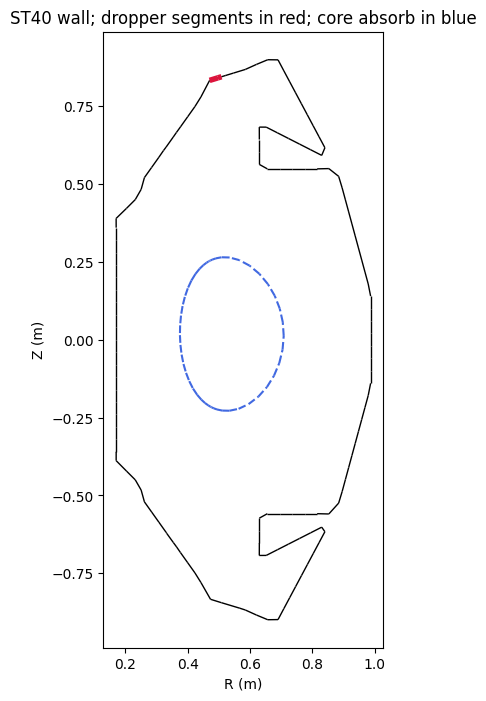

In [12]:
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection

%matplotlib inline

def read_surf(path):
    pts, lines, section = {}, [], None
    for s in Path(path).read_text().splitlines():
        s = s.strip()
        if s.lower() in ("points", "lines"): section = s.lower(); continue
        if section is None or not s or not s[0].isdigit(): continue
        p = s.split()
        if section == "points": pts[int(p[0])] = (float(p[2]), float(p[1]))  # (R, Z)
        elif len(p) == 3: lines.append(tuple(map(int, p)))
    return pts, lines

pts0, lines0 = read_surf(INP/"st40_wall_axi.surf")
ptsc, linesc = read_surf(INP/"st40_core.surf")

fig, ax = plt.subplots(figsize=(6, 8))
ax.add_collection(LineCollection([[pts0[a], pts0[b]] for _, a, b in lines0], colors="k", lw=1))
ax.add_collection(LineCollection([[pts0[a], pts0[b]] for i, a, b in lines0 if i in (15, 16)],
                                 colors="crimson", lw=4))
ax.add_collection(LineCollection([[ptsc[a], ptsc[b]] for _, a, b in linesc],
                                 colors="royalblue", lw=1.5, linestyle="--"))
ax.autoscale(); ax.set_aspect("equal")
ax.set_xlabel("R (m)"); ax.set_ylabel("Z (m)")
ax.set_title("ST40 wall; dropper segments in red; core absorb in blue")


## 2. Input provenance

Needs the SOLPS source data; fresh clones use the committed `input/` files.

The h5 was built with `tools/converters/convert_solps_plasma.py` from
`/Users/42d/Downloads/13589` (run_dir + baserun b2fgmtry + EFIT geqdsk).
The electric field (`mesh/e_r,e_z,e_t`, E = −∇φ from the fort.31 potential)
was filled in afterwards with `tools/converters/add_efield_from_po.py`
(2026-08-04); the converter now also falls back to `po` from b2fstate, so a
fresh conversion gets E without `balance.nc`. `mesh/q_par` (heat flux from
SOLPS face fluxes) and `/wall_flux/` are carried in the same file.

## 3. Results: per-species Li density maps + species-vs-time history

`plot_density()` auto-picks the pulse-peak frame (pass `step=` for another);
`plot_history()` reads the per-species counts from the `stats_style` block in
`log.openedge`. The camera-style particle scatter (`plot_lpd.main()`) needs
the particle dump re-enabled in `in.openedge`.

In [15]:
# plot_lpd.main()
# from IPython.display import Image
# Image(str(ROOT/"st40_lpd_chain.png"))


In [16]:
from IPython.display import Image
plot_lpd.plot_density()          # per-species panels + total; step=<N> for a specific frame
Image(str(ROOT/"st40_li_density.png"))

frames (step, total): [(0, '0.00e+00'), (10000, '0.00e+00'), (20000, '0.00e+00')] -> plotting 0


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x10be03550> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1300x600 with 6 Axes>

wrote /Users/42d/OpenEdge/examples/workflows/particulates/st40_lithium_powder_dropper/st40_li_history.png | 101 stats samples


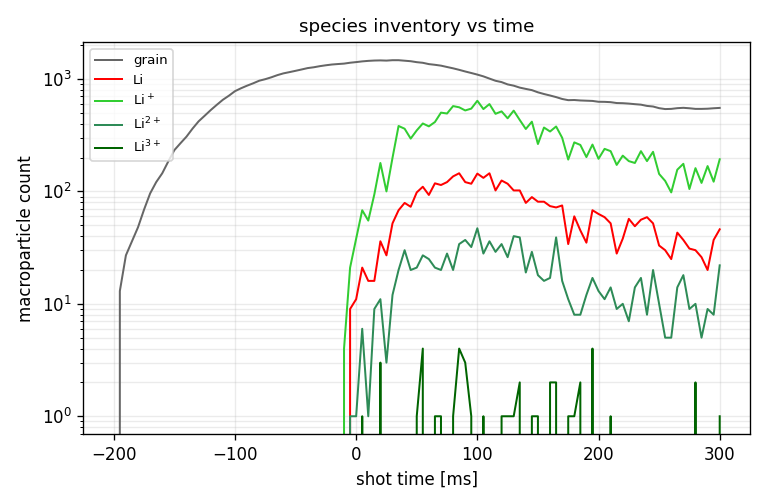

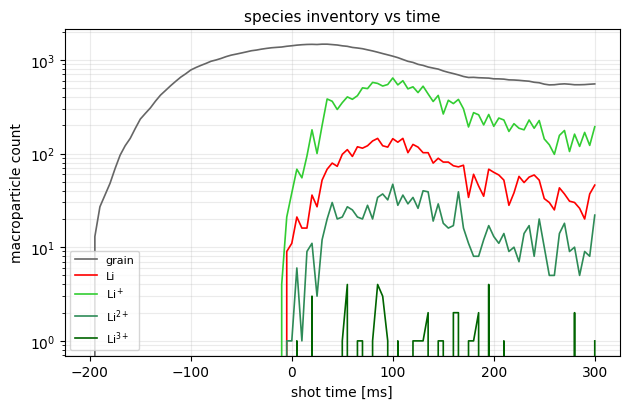

In [58]:
plot_lpd.plot_history()          # species inventories vs shot time from log.openedge stats
Image(str(ROOT/"st40_li_history.png"))